# Desbalance extremo: Focal Loss y Cost-Sensitive Pipelines

**Topico avanzado — Aprendizaje de Maquina Aplicado (ST1613, EAFIT 2026-1)**

Equipo: David Franco, (compañero 2), (compañero 3)

---

Cuando una clase es muy rara (fraudes, enfermedades, fallas industriales), los modelos
de ML estandar tienden a ignorarla porque la perdida promedio se domina por la clase
mayoritaria. Un clasificador trivial que diga "nunca hay fraude" puede tener 99.8% de
accuracy y aun asi ser inutil.

En esta exposicion vamos a:

1. Mostrar **por que** las metricas tradicionales engañan en estos casos.
2. Atacar el problema con **cost-sensitive learning** (`class_weight`, `scale_pos_weight`, ajuste de umbral).
3. Atacar el problema con **Focal Loss** (Lin et al., 2017), una funcion de perdida que
   redirige el gradiente hacia los ejemplos dificiles.
4. Comparar de forma honesta las tecnicas en un dataset real de fraude bancario,
   usando un split **temporal** de tres partes (train/val/test) para evitar data leakage.

## 1. Contexto: ¿que es desbalance extremo?

En clasificacion binaria solemos hablar de tres regimenes:

| Ratio positivo:negativo | Categoria | Ejemplos |
|---|---|---|
| 1:1 a 1:4 | balanceado / leve | clasificacion de sentimiento, imagenes |
| 1:10 a 1:100 | moderado | churn, spam, conversion publicitaria |
| 1:1000 o peor | **extremo** | fraude bancario, deteccion de tumores raros, fallas en produccion |

El problema no es solo estadistico, es practico: en fraude un FN (dejar pasar una
transaccion fraudulenta) puede costar miles de dolares, mientras que un FP (revisar
una transaccion legitima por error) cuesta unos pocos centavos de operacion. Las
metricas y la funcion de perdida tienen que reflejar eso.

## 2. Setup y carga de datos

Usamos el dataset **Credit Card Fraud Detection** (Kaggle, `mlg-ulb/creditcardfraud`).
Si no esta descargado localmente, el notebook intenta traerlo desde OpenML, y como
ultimo recurso genera datos sinteticos equivalentes.

In [1]:
import sys
from pathlib import Path

# permitir importar desde src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

import xgboost as xgb

from src.metrics import (
    evaluate, summary_table, plot_pr_curves,
    best_threshold_for_recall, cost_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

In [2]:
def load_creditcard() -> pd.DataFrame:
    """Carga el dataset con fallbacks."""
    raw_path = ROOT / "data" / "raw" / "creditcard.csv"
    if raw_path.exists():
        print(f"[OK] Cargando desde {raw_path}")
        return pd.read_csv(raw_path)

    print("[INFO] No se encontro creditcard.csv local. Intentando OpenML...")
    try:
        from sklearn.datasets import fetch_openml
        bunch = fetch_openml(name="creditcardfraud", version=1, as_frame=True, parser="auto")
        df = bunch.frame.copy()
        df.rename(columns={"Class": "Class"}, inplace=True)
        df["Class"] = df["Class"].astype(int)
        return df
    except Exception as e:
        print(f"[WARN] OpenML fallo: {e}")
        print("[INFO] Generando dataset sintetico con desbalance extremo (solo para demo)")
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=100_000, n_features=30, n_informative=15,
            weights=[0.998, 0.002], random_state=RANDOM_STATE
        )
        cols = [f"V{i}" for i in range(1, 29)] + ["Time", "Amount"]
        df = pd.DataFrame(X, columns=cols)
        df["Class"] = y
        return df


df = load_creditcard()
print(f"Shape: {df.shape}")
df.head()

[OK] Cargando desde D:\Programming\EAFIT\ML\Exposicion ML\data\raw\creditcard.csv


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. EDA rapido: cuan extremo es el desbalance

Lo importante aqui no es hacer un EDA exhaustivo (eso seria para el proyecto), sino
**dimensionar el problema**: ¿que tan pocas instancias positivas hay?

In [3]:
print("Distribucion de clases:")
print(df["Class"].value_counts())
print()
print(f"Proporcion de positivos: {df['Class'].mean()*100:.4f}%")
print(f"Ratio negativo:positivo = {(df['Class']==0).sum() / max((df['Class']==1).sum(), 1):.1f} : 1")

Distribucion de clases:
Class
0    284315
1       492
Name: count, dtype: int64

Proporcion de positivos: 0.1727%
Ratio negativo:positivo = 577.9 : 1


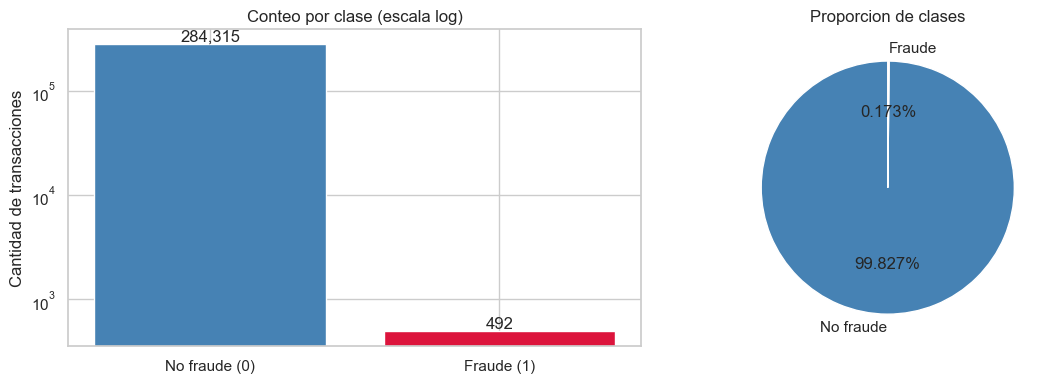

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["Class"].value_counts().sort_index()
axes[0].bar(["No fraude (0)", "Fraude (1)"], counts.values, color=["steelblue", "crimson"])
axes[0].set_yscale("log")
axes[0].set_title("Conteo por clase (escala log)")
axes[0].set_ylabel("Cantidad de transacciones")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(
    counts.values, labels=["No fraude", "Fraude"],
    colors=["steelblue", "crimson"], autopct="%1.3f%%", startangle=90,
)
axes[1].set_title("Proporcion de clases")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "01_class_balance.png", bbox_inches="tight", dpi=120)
plt.show()

## 4. Split temporal train/val/test (60/20/20)

En fraude bancario los patrones cambian en el tiempo: tarjetas comprometidas, nuevas
tecnicas, estacionalidad. Hacer un split aleatorio (`train_test_split` con shuffle)
mezcla transacciones del futuro y del pasado, lo que **infla artificialmente** las
metricas — el modelo ve patrones del "futuro" durante el entrenamiento.

Para evitar eso:

1. **Ordenamos por `Time`** (segundos desde la primera transaccion).
2. **Tres particiones cronologicas**: train (60% mas antiguo), val (20% del medio),
   test (20% mas reciente).
3. **Val** se usa para tunear umbrales, $\gamma$, $\alpha$ y elegir modelos.
4. **Test** se reporta UNA sola vez al final, sin tocarlo en el camino.

Asi evitamos dos formas de leakage:
- **Temporal**: usar futuro para predecir pasado.
- **De evaluacion**: optimizar hiperparametros sobre la misma particion que reportamos.

In [5]:
# orden cronologico
df_sorted = df.sort_values("Time").reset_index(drop=True)

n = len(df_sorted)
n_train = int(0.60 * n)
n_val = int(0.20 * n)

train_df = df_sorted.iloc[:n_train].copy()
val_df = df_sorted.iloc[n_train:n_train + n_val].copy()
test_df = df_sorted.iloc[n_train + n_val:].copy()

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"].astype(int)
X_val = val_df.drop(columns=["Class"])
y_val = val_df["Class"].astype(int)
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"].astype(int)

print("Particiones (orden cronologico):")
print(f"  Train: {X_train.shape}  -  positivos: {y_train.sum():3d}  ({y_train.mean()*100:.3f}%)")
print(f"  Val:   {X_val.shape}    -  positivos: {y_val.sum():3d}  ({y_val.mean()*100:.3f}%)")
print(f"  Test:  {X_test.shape}    -  positivos: {y_test.sum():3d}  ({y_test.mean()*100:.3f}%)")
print()
print(f"  Time min train: {train_df['Time'].min():.0f}s")
print(f"  Time max train: {train_df['Time'].max():.0f}s")
print(f"  Time min val:   {val_df['Time'].min():.0f}s")
print(f"  Time max val:   {val_df['Time'].max():.0f}s")
print(f"  Time min test:  {test_df['Time'].min():.0f}s")
print(f"  Time max test:  {test_df['Time'].max():.0f}s")

Particiones (orden cronologico):
  Train: (170884, 30)  -  positivos: 360  (0.211%)
  Val:   (56961, 30)    -  positivos:  57  (0.100%)
  Test:  (56962, 30)    -  positivos:  75  (0.132%)

  Time min train: 0s
  Time max train: 120396s
  Time min val:   120396s
  Time max val:   145247s
  Time min test:  145248s
  Time max test:  172792s


**Nota:** las proporciones de positivos varian entre splits porque el split es
temporal (no estratificado). Esto refleja la realidad: los fraudes no se distribuyen
uniformemente en el tiempo. Si en algun split tenemos muy pocos positivos las
metricas tendran alta varianza, pero es honesto.

## 5. Baseline naive y el "accuracy paradox"

Antes de meter cualquier tecnica, veamos que pasa con un clasificador que **siempre
predice la clase mayoritaria** (no-fraude). Es el peor modelo posible, pero su
accuracy va a sorprender.

In [6]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy del clasificador trivial 'siempre digo 0' sobre TEST: {acc*100:.3f}%")
print(f"Recall sobre fraudes en TEST: {(y_pred_baseline[y_test==1]==1).mean()*100:.1f}%")
print(f"Es decir: deja pasar TODOS los fraudes.")

Accuracy del clasificador trivial 'siempre digo 0' sobre TEST: 99.868%
Recall sobre fraudes en TEST: 0.0%
Es decir: deja pasar TODOS los fraudes.


**El accuracy paradox:** un modelo con 99.8% de accuracy es inutil para detectar
fraude. Por eso en desbalance extremo:

- ❌ `accuracy` **no sirve**.
- ⚠️  `ROC-AUC` puede ser engañoso (es generoso cuando hay muchos negativos).
- ✅ **`PR-AUC` (Average Precision)** es la metrica primaria — y es **threshold-free**.
- ✅ Reportar tambien **recall** y **precision** a un umbral practico.
- ✅ Si se conocen los costos, calcular **costo total** (cost_fp * FP + cost_fn * FN).

## 6. Funciones auxiliares para evaluacion honesta

Definimos un par de helpers que aplican consistentemente la misma logica:
**tunear sobre val, reportar sobre test**.

In [7]:
def fit_predict(model, X_tr, y_tr, X_val, X_te):
    """Entrena en train, devuelve scores en val y test."""
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        sv = model.predict_proba(X_val)[:, 1]
        st = model.predict_proba(X_te)[:, 1]
    else:
        sv = model.decision_function(X_val)
        st = model.decision_function(X_te)
    return sv, st


def tune_threshold_for_cost(y_val, score_val, cost_fp=1.0, cost_fn=100.0):
    """Devuelve el umbral que minimiza costo total sobre val."""
    thresholds = np.linspace(0.001, 0.999, 200)
    costs = [
        cost_score(y_val, (score_val >= t).astype(int), cost_fp, cost_fn)
        for t in thresholds
    ]
    return float(thresholds[int(np.argmin(costs))])


def report_test(name, y_te, score_te, threshold):
    """Evalua sobre test y devuelve EvalResult."""
    return evaluate(name, y_te, score_te, threshold=threshold)

## 7. Baseline real: regresion logistica sin ajuste

Entrenamos en `train`, tuneamos umbral en `val`, reportamos en `test`.

In [8]:
pipe_lr_naive = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
sv_naive, st_naive = fit_predict(pipe_lr_naive, X_train, y_train, X_val, X_test)

thr_naive = tune_threshold_for_cost(y_val, sv_naive)
res_naive = report_test("LR sin ajuste", y_test, st_naive, thr_naive)
print(f"Umbral elegido en val: {thr_naive:.4f}")
print(pd.Series(res_naive.as_row()))

Umbral elegido en val: 0.0512
modelo       LR sin ajuste
PR-AUC              0.6926
ROC-AUC             0.9731
Precision           0.4651
Recall                 0.8
F1                  0.5882
Umbral               0.051
TP                      60
FP                      69
FN                      15
TN                   56818
dtype: object


## 8. Familia 1: Cost-Sensitive Learning

Idea: si la clase positiva es rara pero importante, **subile el peso** a sus errores
en la funcion de perdida.

Matematicamente: cross-entropy estandar es
$$
\mathcal{L} = -\sum_i \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]
$$
y cost-sensitive simplemente la convierte en
$$
\mathcal{L}_w = -\sum_i w_i \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]
$$
donde $w_i$ es mayor para la clase minoritaria. Si la clase positiva es el 0.2%,
ponemos $w_+ \approx 500 \cdot w_-$ y el modelo "siente" como si hubiera tantos
positivos como negativos.

### 8.1 Regresion logistica con `class_weight='balanced'`

In [9]:
pipe_lr_cw = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])
sv_cw, st_cw = fit_predict(pipe_lr_cw, X_train, y_train, X_val, X_test)
thr_cw = tune_threshold_for_cost(y_val, sv_cw)
res_cw = report_test("LR + class_weight", y_test, st_cw, thr_cw)
print(f"Umbral elegido en val: {thr_cw:.4f}")
print(pd.Series(res_cw.as_row()))

Umbral elegido en val: 0.8786
modelo       LR + class_weight
PR-AUC                  0.7432
ROC-AUC                 0.9821
Precision               0.2148
Recall                  0.8533
F1                      0.3432
Umbral                   0.879
TP                          64
FP                         234
FN                          11
TN                       56653
dtype: object


### 8.2 XGBoost con y sin `scale_pos_weight`

In [10]:
neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight a usar: {neg_pos_ratio:.1f}")

xgb_naive = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="aucpr",
    n_jobs=-1, verbosity=0,
)
sv_xn, st_xn = fit_predict(xgb_naive, X_train, y_train, X_val, X_test)
thr_xn = tune_threshold_for_cost(y_val, sv_xn)
res_xgb_naive = report_test("XGB sin ajuste", y_test, st_xn, thr_xn)

xgb_cs = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=neg_pos_ratio,
    random_state=RANDOM_STATE, eval_metric="aucpr",
    n_jobs=-1, verbosity=0,
)
sv_xcs, st_xcs = fit_predict(xgb_cs, X_train, y_train, X_val, X_test)
thr_xcs = tune_threshold_for_cost(y_val, sv_xcs)
res_xgb_cs = report_test("XGB + scale_pos_weight", y_test, st_xcs, thr_xcs)

pd.DataFrame([res_xgb_naive.as_row(), res_xgb_cs.as_row()]).set_index("modelo")

scale_pos_weight a usar: 473.7


,PR-AUC,ROC-AUC,Precision,Recall,F1,Umbral,TP,FP,FN,TN
modelo,,,,,,,,,,
XGB sin ajuste,0.7275,0.9720,0.3631,0.7600,0.4914,0.001,57,100,18,56787
XGB + scale_pos_weight,0.7852,0.9716,0.6374,0.7733,0.6988,0.021,58,33,17,56854


### 8.3 Ajuste de umbral (sobre VAL, no test)

`predict()` usa umbral 0.5 por default. En desbalance extremo mover el umbral es a
veces mas efectivo que cambiar el modelo. **Importante:** elegir el umbral mirando
la curva PR del set de **validacion**, no del test. Si lo eligieramos en test,
estariamos optimizando sobre la misma particion que reportamos = leakage.

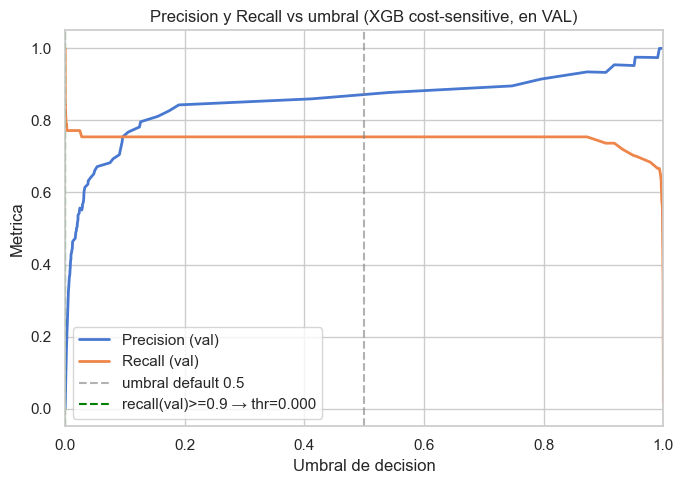

In [11]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_val, sv_xcs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thr, prec[:-1], label="Precision (val)", linewidth=2)
ax.plot(thr, rec[:-1], label="Recall (val)", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="umbral default 0.5")

target_recall = 0.90
mask = rec[:-1] >= target_recall
if mask.any():
    idx = np.argmax(prec[:-1][mask])
    thr_for_recall = thr[mask][idx]
    ax.axvline(thr_for_recall, color="green", linestyle="--",
               label=f"recall(val)>=0.9 → thr={thr_for_recall:.3f}")
ax.set_xlabel("Umbral de decision")
ax.set_ylabel("Metrica")
ax.set_title("Precision y Recall vs umbral (XGB cost-sensitive, en VAL)")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "02_threshold_tuning.png", bbox_inches="tight", dpi=120)
plt.show()

In [12]:
# aplicar ese umbral sobre TEST (umbral elegido en val, reporte en test)
res_xgb_tuned = report_test("XGB + scale_pos_weight + thr(recall>=0.9)",
                            y_test, st_xcs, thr_for_recall)
pd.Series(res_xgb_tuned.as_row())

modelo       XGB + scale_pos_weight + thr(recall>=0.9)
PR-AUC                                          0.7852
ROC-AUC                                         0.9716
Precision                                       0.0106
Recall                                          0.9067
F1                                              0.0209
Umbral                                             0.0
TP                                                  68
FP                                                6365
FN                                                   7
TN                                               50522
dtype: object

### 8.4 Costos asimetricos

En fraude bancario, dejar pasar un fraude (FN) es mucho mas caro que revisar una
transaccion limpia (FP). Modelamos `cost_fp = 1` y `cost_fn = 100`, buscamos el
umbral que **minimiza el costo total en val**, y reportamos el costo en test.

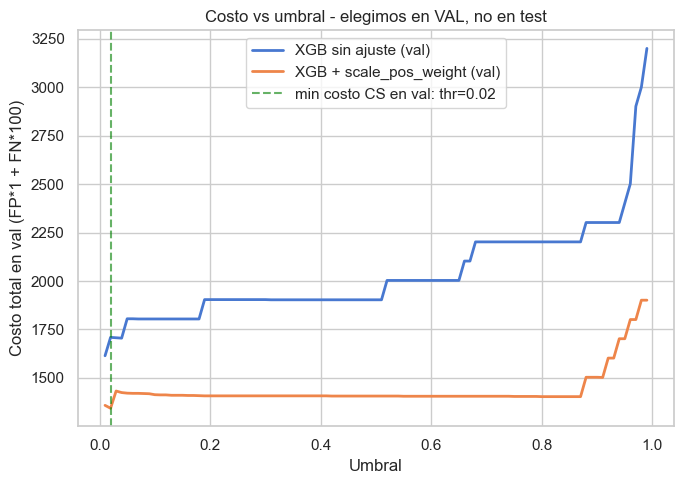

Umbral seleccionado (en val): 0.020
Costo minimo en val:           1343
Costo en test con ese umbral:  1733


In [13]:
def cost_at_threshold(y_true, y_score, threshold, cost_fp=1.0, cost_fn=100.0):
    y_pred = (y_score >= threshold).astype(int)
    return cost_score(y_true, y_pred, cost_fp, cost_fn)

thresholds = np.linspace(0.01, 0.99, 99)
costs_xn_val = [cost_at_threshold(y_val, sv_xn, t) for t in thresholds]
costs_xcs_val = [cost_at_threshold(y_val, sv_xcs, t) for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, costs_xn_val, label="XGB sin ajuste (val)", linewidth=2)
ax.plot(thresholds, costs_xcs_val, label="XGB + scale_pos_weight (val)", linewidth=2)
best_t_xcs_val = thresholds[np.argmin(costs_xcs_val)]
ax.axvline(best_t_xcs_val, color="green", linestyle="--", alpha=0.6,
           label=f"min costo CS en val: thr={best_t_xcs_val:.2f}")
ax.set_xlabel("Umbral")
ax.set_ylabel("Costo total en val (FP*1 + FN*100)")
ax.set_title("Costo vs umbral - elegimos en VAL, no en test")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "figures" / "03_cost_curve.png", bbox_inches="tight", dpi=120)
plt.show()

# costo final reportado en TEST
costo_test = cost_at_threshold(y_test, st_xcs, best_t_xcs_val)
print(f"Umbral seleccionado (en val): {best_t_xcs_val:.3f}")
print(f"Costo minimo en val:           {min(costs_xcs_val):.0f}")
print(f"Costo en test con ese umbral:  {costo_test:.0f}")

## 9. Familia 2: Focal Loss

Focal Loss aparece en *Focal Loss for Dense Object Detection* (Lin et al., 2017,
RetinaNet). Atacan el problema de detectores densos donde hay miles de "background
anchors" por cada objeto real — un caso de desbalance extremo.

Idea central: **no todos los ejemplos son iguales**. Un ejemplo facil que el modelo
ya clasifica con 99% de confianza no tiene mucho que enseñarle. La cross-entropy le
sigue dando una perdida pequeña pero no nula, y como hay millones de ejemplos faciles,
**dominan el gradiente** y opacan los pocos ejemplos dificiles.

Focal loss reescala la perdida para que los ejemplos faciles aporten casi nada.

### 9.1 Derivacion: de cross-entropy a focal loss

Sea $p_t$ la probabilidad asignada a la clase verdadera:

$$
p_t = \begin{cases} p & \text{si } y=1 \\ 1-p & \text{si } y=0 \end{cases}
$$

Cross-entropy en esa forma es $\text{CE}(p_t) = -\log(p_t)$.

**Focal loss** introduce un factor modulador $(1 - p_t)^\gamma$:

$$
\boxed{\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)}
$$

- Cuando $p_t \to 1$ (ejemplo bien clasificado), $(1-p_t)^\gamma \to 0$, perdida aplastada.
- Cuando $p_t \to 0$ (ejemplo dificil), $(1-p_t)^\gamma \to 1$, perdida intacta.
- $\alpha_t$ hace el papel de `class_weight` (peso de balance por clase).
- $\gamma$ controla cuanto se aplastan los faciles. El paper recomienda $\gamma = 2$, $\alpha = 0.25$.

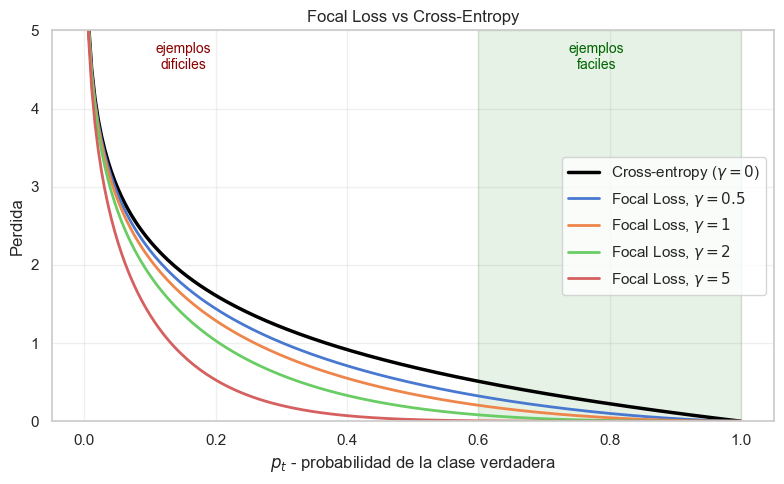

In [14]:
p_t = np.linspace(0.001, 0.999, 200)
ce = -np.log(p_t)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_t, ce, label=r"Cross-entropy ($\gamma=0$)", linewidth=2.5, color="black")
for g in [0.5, 1, 2, 5]:
    fl = (1 - p_t) ** g * (-np.log(p_t))
    ax.plot(p_t, fl, label=rf"Focal Loss, $\gamma={g}$", linewidth=2)
ax.set_xlabel(r"$p_t$ - probabilidad de la clase verdadera")
ax.set_ylabel("Perdida")
ax.set_title("Focal Loss vs Cross-Entropy")
ax.legend()
ax.set_ylim(0, 5)
ax.grid(alpha=0.3)
ax.axvspan(0.6, 1.0, alpha=0.1, color="green")
ax.text(0.78, 4.5, "ejemplos\nfaciles", ha="center", color="darkgreen", fontsize=10)
ax.text(0.15, 4.5, "ejemplos\ndificiles", ha="center", color="darkred", fontsize=10)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "04_focal_loss_shape.png", bbox_inches="tight", dpi=120)
plt.show()

**Lectura:** con $\gamma = 2$, un ejemplo a 0.9 de confianza tiene perdida 100 veces
menor que con CE. El gradiente se concentra en los ejemplos dificiles, justo lo que
necesitamos cuando los positivos son raros.

### 9.2 Implementacion en PyTorch

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from src.focal_loss import FocalLossBinary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# escalar features sobre train solamente
scaler_nn = StandardScaler()
X_train_sc = scaler_nn.fit_transform(X_train)
X_val_sc = scaler_nn.transform(X_val)
X_test_sc = scaler_nn.transform(X_test)

X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32)
X_v_t = torch.tensor(X_val_sc, dtype=torch.float32)
y_v_t = torch.tensor(y_val.values, dtype=torch.float32)
X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)
y_te_t = torch.tensor(y_test.values, dtype=torch.float32)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)

Device: cpu


In [16]:
class SimpleNN(nn.Module):
    """Red simple para clasificacion binaria. La idea no es la arquitectura,
    es comparar cross-entropy vs focal loss bajo la misma red."""
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_nn(loss_fn, epochs=20, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    model = SimpleNN(X_tr_t.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    losses = []
    for ep in range(epochs):
        ep_loss = 0.0
        n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * xb.size(0)
            n += xb.size(0)
        losses.append(ep_loss / n)
    return model, losses


def predict_proba_nn(model, X_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

In [17]:
print("Entrenando NN con BCE...")
model_bce, losses_bce = train_nn(nn.BCEWithLogitsLoss(), epochs=20)
sv_nn_bce = predict_proba_nn(model_bce, X_v_t)
st_nn_bce = predict_proba_nn(model_bce, X_te_t)
thr_nn_bce = tune_threshold_for_cost(y_val.values, sv_nn_bce)
res_nn_bce = report_test("NN + BCE", y_test, st_nn_bce, thr_nn_bce)
print(pd.Series(res_nn_bce.as_row()))

Entrenando NN con BCE...


modelo       NN + BCE
PR-AUC         0.8032
ROC-AUC        0.9739
Precision      0.6452
Recall            0.8
F1             0.7143
Umbral          0.006
TP                 60
FP                 33
FN                 15
TN              56854
dtype: object


In [18]:
print("Entrenando NN con Focal Loss (alpha=0.25, gamma=2)...")
focal = FocalLossBinary(alpha=0.25, gamma=2.0)
model_fl, losses_fl = train_nn(focal, epochs=20)
sv_nn_fl = predict_proba_nn(model_fl, X_v_t)
st_nn_fl = predict_proba_nn(model_fl, X_te_t)
thr_nn_fl = tune_threshold_for_cost(y_val.values, sv_nn_fl)
res_nn_fl = report_test("NN + Focal Loss (gamma=2)", y_test, st_nn_fl, thr_nn_fl)
print(pd.Series(res_nn_fl.as_row()))

Entrenando NN con Focal Loss (alpha=0.25, gamma=2)...


modelo       NN + Focal Loss (gamma=2)
PR-AUC                          0.8063
ROC-AUC                         0.9727
Precision                       0.6452
Recall                             0.8
F1                              0.7143
Umbral                           0.101
TP                                  60
FP                                  33
FN                                  15
TN                               56854
dtype: object


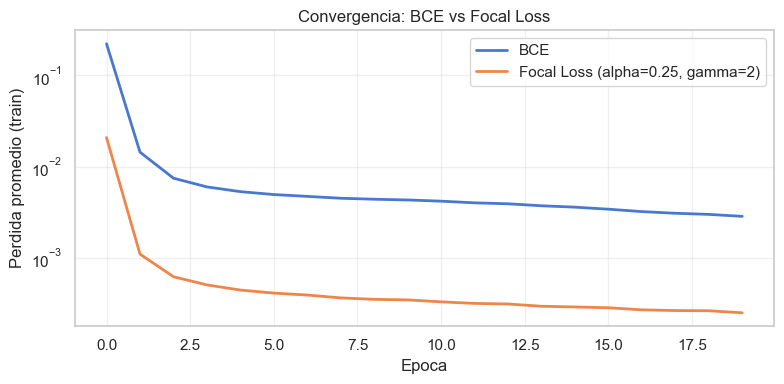

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_bce, label="BCE", linewidth=2)
ax.plot(losses_fl, label="Focal Loss (alpha=0.25, gamma=2)", linewidth=2)
ax.set_xlabel("Epoca")
ax.set_ylabel("Perdida promedio (train)")
ax.set_title("Convergencia: BCE vs Focal Loss")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "05_training_curves.png", bbox_inches="tight", dpi=120)
plt.show()

**Importante:** los valores absolutos de loss no son comparables entre BCE y Focal
(escalas distintas). Lo que importa es la metrica de evaluacion en test.

### 9.3 Seleccion de $\gamma$ usando val (no test)

Entrenamos varios modelos con diferentes $\gamma$, evaluamos en VAL para elegir el
mejor, y solo despues reportamos en TEST.

In [20]:
from sklearn.metrics import average_precision_score

gammas = [0.0, 1.0, 2.0, 5.0]
gamma_results = []
for g in gammas:
    print(f"  Entrenando gamma={g}...")
    fl = FocalLossBinary(alpha=0.25, gamma=g)
    m, _ = train_nn(fl, epochs=15)
    sv = predict_proba_nn(m, X_v_t)
    st = predict_proba_nn(m, X_te_t)
    pr_val = average_precision_score(y_val, sv)
    pr_test = average_precision_score(y_test, st)
    gamma_results.append({
        "gamma": g,
        "PR-AUC val": round(pr_val, 4),
        "PR-AUC test": round(pr_test, 4),
        "scores_val": sv,
        "scores_test": st,
    })

# elegir el mejor gamma usando VAL
best_idx = int(np.argmax([r["PR-AUC val"] for r in gamma_results]))
best_gamma = gamma_results[best_idx]["gamma"]
print(f"\nMejor gamma segun val: {best_gamma}")

# tabla limpia para mostrar
gamma_table = pd.DataFrame([
    {"gamma": r["gamma"], "PR-AUC val": r["PR-AUC val"], "PR-AUC test": r["PR-AUC test"]}
    for r in gamma_results
])
gamma_table

  Entrenando gamma=0.0...


  Entrenando gamma=1.0...


  Entrenando gamma=2.0...


  Entrenando gamma=5.0...



Mejor gamma segun val: 2.0


,gamma,PR-AUC val,PR-AUC test
0,0.0,0.7420,0.8055
1,1.0,0.7520,0.8099
2,2.0,0.7569,0.8102
3,5.0,0.7566,0.7986


In [21]:
# evaluacion final del mejor gamma sobre test (con umbral tuneado en val)
best_sv = gamma_results[best_idx]["scores_val"]
best_st = gamma_results[best_idx]["scores_test"]
thr_best_fl = tune_threshold_for_cost(y_val.values, best_sv)
res_nn_fl_best = report_test(f"NN + FL (gamma={best_gamma})*",
                             y_test, best_st, thr_best_fl)
print(pd.Series(res_nn_fl_best.as_row()))

modelo       NN + FL (gamma=2.0)*
PR-AUC                     0.8102
ROC-AUC                    0.9751
Precision                  0.4207
Recall                     0.8133
F1                         0.5545
Umbral                      0.071
TP                             61
FP                             84
FN                             14
TN                          56803
dtype: object


## 10. Comparacion final — todas las metricas sobre TEST

Cada modelo se entreno en `train`, su umbral fue tuneado en `val`, y las metricas
se reportan **una sola vez sobre `test`**.

In [22]:
all_results = [
    res_naive,
    res_cw,
    res_xgb_naive,
    res_xgb_cs,
    res_xgb_tuned,
    res_nn_bce,
    res_nn_fl,
    res_nn_fl_best,
]
tbl = summary_table(all_results)
tbl

,PR-AUC,ROC-AUC,Precision,Recall,F1,Umbral,TP,FP,FN,TN
modelo,,,,,,,,,,
LR sin ajuste,0.6926,0.9731,0.4651,0.8000,0.5882,0.051,60,69,15,56818
LR + class_weight,0.7432,0.9821,0.2148,0.8533,0.3432,0.879,64,234,11,56653
XGB sin ajuste,0.7275,0.9720,0.3631,0.7600,0.4914,0.001,57,100,18,56787
XGB + scale_pos_weight,0.7852,0.9716,0.6374,0.7733,0.6988,0.021,58,33,17,56854
XGB + scale_pos_weight + thr(recall>=0.9),0.7852,0.9716,0.0106,0.9067,0.0209,0.000,68,6365,7,50522
NN + BCE,0.8032,0.9739,0.6452,0.8000,0.7143,0.006,60,33,15,56854
NN + Focal Loss (gamma=2),0.8063,0.9727,0.6452,0.8000,0.7143,0.101,60,33,15,56854
NN + FL (gamma=2.0)*,0.8102,0.9751,0.4207,0.8133,0.5545,0.071,61,84,14,56803


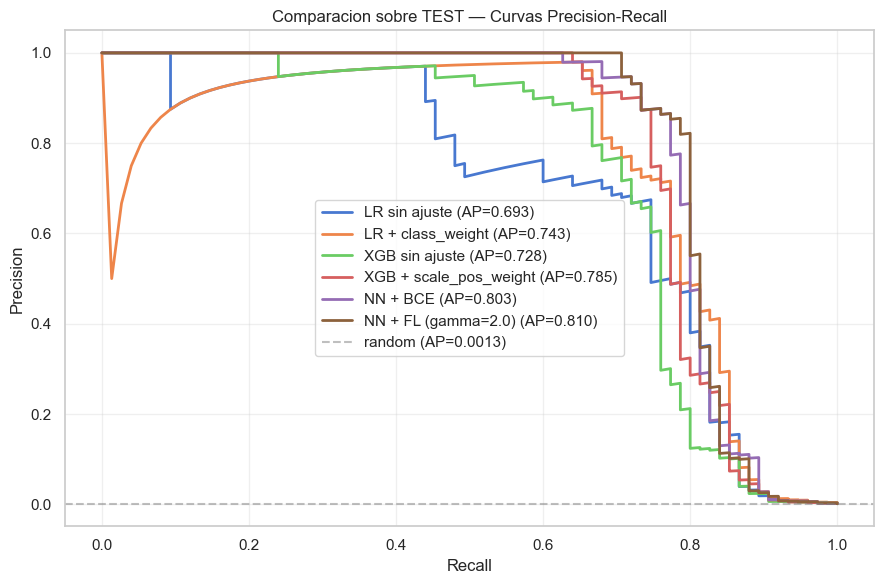

In [23]:
# curvas PR sobre TEST
scores_to_plot = {
    "LR sin ajuste": (y_test, st_naive),
    "LR + class_weight": (y_test, st_cw),
    "XGB sin ajuste": (y_test, st_xn),
    "XGB + scale_pos_weight": (y_test, st_xcs),
    "NN + BCE": (y_test, st_nn_bce),
    f"NN + FL (gamma={best_gamma})": (y_test, best_st),
}

fig, ax = plt.subplots(figsize=(9, 6))
plot_pr_curves(scores_to_plot, ax=ax)
ax.set_title("Comparacion sobre TEST — Curvas Precision-Recall")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "06_pr_curves_final.png", bbox_inches="tight", dpi=120)
plt.show()

In [24]:
# costo total en test, con umbral tuneado en val
print("Costo en TEST con umbral tuneado en VAL (FP=$1, FN=$100):")
print()
def cost_test_at_thr_val(yv, sv, yt, st, cost_fp=1.0, cost_fn=100.0):
    t = tune_threshold_for_cost(yv, sv, cost_fp, cost_fn)
    yp_test = (st >= t).astype(int)
    return cost_score(yt, yp_test, cost_fp, cost_fn), t

print(f"  {'modelo':<32}  {'costo':>8}  {'thr(val)':>10}")
for name, (sv, st) in [
    ("LR sin ajuste", (sv_naive, st_naive)),
    ("LR + class_weight", (sv_cw, st_cw)),
    ("XGB sin ajuste", (sv_xn, st_xn)),
    ("XGB + scale_pos_weight", (sv_xcs, st_xcs)),
    ("NN + BCE", (sv_nn_bce, st_nn_bce)),
    (f"NN + FL (gamma={best_gamma})", (best_sv, best_st)),
]:
    c, t = cost_test_at_thr_val(y_val.values, sv, y_test.values, st)
    print(f"  {name:<32}  {c:>8.0f}  {t:>10.3f}")

Costo en TEST con umbral tuneado en VAL (FP=$1, FN=$100):

  modelo                               costo    thr(val)


  LR sin ajuste                         1569       0.051


  LR + class_weight                     1334       0.879


  XGB sin ajuste                        1900       0.001


  XGB + scale_pos_weight                1733       0.021


  NN + BCE                              1533       0.006


  NN + FL (gamma=2.0)                   1484       0.071


## 11. Conclusiones y cuando usar cada tecnica

### Resumen ejecutivo

| Si tu situacion es... | Tecnica recomendada |
|---|---|
| Primera iteracion, modelo lineal o arbol | `class_weight='balanced'` o `scale_pos_weight` |
| El umbral default no aplica al negocio | Ajustar umbral por curva PR sobre val |
| Costos asimetricos conocidos | Minimizar costo total sobre val, reportar en test |
| Red neuronal, desbalance muy fuerte | **Focal Loss** con $\gamma$ y $\alpha$ tuneados |
| Pocos datos positivos absolutos (<100) | Combinar con oversampling moderado (SMOTE) |
| Necesitas interpretabilidad | Cost-sensitive en LR o XGBoost, evitar focal loss |

### Tres ideas que se llevan de la expo

1. **Accuracy es inutil en desbalance extremo.** Usen PR-AUC + costo total. PR-AUC
   es threshold-free, asi que no se contamina con leakage de umbral.

2. **Cost-sensitive es la solucion barata y suficiente para el 80% de los casos.**
   No mover el dataset, mover los pesos. Tres lineas de codigo en sklearn o XGBoost.

3. **Focal Loss brilla cuando hay capacidad sobrante** (redes neuronales). Pero
   $\gamma$ y $\alpha$ se deben tunear en validacion, no en test. Para tabular puro
   con arboles, normalmente no aporta mucho sobre `scale_pos_weight` bien tuneado.

### Sobre el rigor experimental

Este notebook usa **split temporal train/val/test (60/20/20)** y **todos los
hiperparametros (umbrales, $\gamma$) se tunean en val**, no en test. Esto evita
dos formas de leakage:

- **Leakage temporal**: usar futuro para entrenar.
- **Leakage de evaluacion**: optimizar sobre la misma particion que reportamos.

Es lo que diferencia un modelo que se ve bien en el notebook de uno que funciona en
produccion.

### Limitaciones

- Un solo dataset, una sola semilla. Para conclusiones robustas habria que repetir
  con varias seeds y/o `TimeSeriesSplit`.
- La red es minima (2 capas). Focal loss puede dar mas ganancia con redes mas grandes.
- No exploramos combinaciones (ej. focal loss + SMOTE).
- Los costos $1 y $100 son ilustrativos. En produccion el modelado de costos
  requiere trabajo con negocio.

### Referencias

- Lin, T. Y., Goyal, P., Girshick, R., He, K., & Dollar, P. (2017). *Focal Loss for
  Dense Object Detection*. ICCV.
- He, H., & Garcia, E. A. (2009). *Learning from Imbalanced Data*. IEEE TKDE.
- Branco, P., Torgo, L., & Ribeiro, R. P. (2016). *A Survey of Predictive Modeling
  on Imbalanced Domains*. ACM Computing Surveys.